# Sharpe-Hacking — a quantitative teardown 🔬
### naive vs autocorrelation-corrected (Lo/GLM) Sharpe · AR(1) smoothing · θ-inflation sweep · leverage invariance · vol-targeting costs · block-bootstrap bands · seed-robust positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Can_engineering_fake_a_Sharpe%3F: Confirmed](https://img.shields.io/badge/Can_engineering_fake_a_Sharpe%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We take a synthetic return stream with an honest Sharpe of ~0.24 and **zero alpha**, apply three Sharpe-gaming transforms, and measure the damage with the metric that can't be gamed.

> ⚠️ **Not investment advice.** A synthetic-only method demo: the tape is built to have zero edge (null fp `807d5cddc33f`), so real free data can never certify it and the study is capped at `NONE`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sharpe_hacking import data, strategy as st

# The whole demo runs on the deterministic, offline seed-590 null tape (honest Sharpe ~0.24, ZERO
# alpha). This is a synthetic-only method demo — there is no real-tape cell by design.
RET, TRUTH = data.synthetic_series(n_days=3000, alpha=0.0, seed=590)
print("null tape:", len(RET), "days,", RET.index[0].date(), "->", RET.index[-1].date(),
      "| honest Sharpe %.2f, alpha %.0f (fp %s)" % (
          st.sharpe_honest_annual(RET.to_numpy()), TRUTH.alpha, data.fingerprint(RET)))


null tape: 3000 days, 2008-01-02 -> 2019-07-02 | honest Sharpe 0.24, alpha 0 (fp 807d5cddc33f)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Smoothing (θ 0.5) inflates the **naive** Sharpe 0.323 → 0.559 (+0.236) while the **honest** Sharpe moves 0.242 → 0.244 (+0.002); leverage ×3 changes *neither*; synthetic-only demo (no real tape). |
| **Tradability** | `MIRAGE` | Vol-targeting gross naive 0.158 → net 0.145 (2 bps); a smoothed Sharpe is unspendable; leverage buys risk, not ratio. |
| **Can engineering fake a Sharpe?** | `CONFIRMED` | Naive Sharpe scales with staleness (0.323 → 0.979 as θ → 0.8); honest-inflation 95% CI `[-0.012, 0.013]` straddles 0. |

> 💡 In plain words: the reported Sharpe is a smoothing artefact; the correction sees through it, and the control proves the honest metric still rewards a *real* edge.

## 1 · The claim, steelmanned

Let $r_t$ be true returns and $\widetilde r_t$ the *reported* series after a transform. The annualised Sharpe is $\widehat{SR} = \bar r / \hat\sigma \cdot \sqrt{252}$.

- **H₁ (smoothing).** An AR(1) smoothing $\widetilde r_t = (1-\theta) r_t + \theta \widetilde r_{t-1}$ preserves $\bar r$ but lowers $\hat\sigma$ and adds positive autocorrelation, so the **naive** $\widehat{SR}$ rises with $\theta$ — with no real return.
- **H₂ (leverage).** $\widetilde r_t = L\,r_t$ scales $\bar r$ and $\hat\sigma$ equally, so $\widehat{SR}$ is *invariant* to $L$.
- **H₃ (vol-targeting).** Rescaling to a constant vol changes $\widehat{SR}$ only if the mean-vol relationship helps — not guaranteed, and not free of turnover.
- **H₄ (the fix).** The Lo (2002) autocorrelation-corrected Sharpe is *invariant* to smoothing: it strips the $\eta(q)$ that naive annualisation gets wrong.

We **confirm H₁** (big naive inflation), **confirm H₂** (exact invariance), **reject the free-lunch reading of H₃** (Sharpe falls here), and **confirm H₄** (honest Sharpe unmoved by smoothing).

## 2 · So what? — the mechanism

The naive Sharpe annualises a daily Sharpe by $\sqrt{252}$, which is **only correct for iid returns**. Smoothing injects serial correlation, so the right factor is Lo's $\eta(q) = q / \sqrt{q + 2\sum_{k<q}(q-k)\rho_k}$, which is *smaller* than $\sqrt{q}$ under positive autocorrelation — exactly cancelling the inflation. This is the same family of correction as the Deflated Sharpe Ratio in [344](../../344-backtest-overfitting/) (there: haircut for *trials*; here: haircut for *autocorrelation*). Getmansky-Lo-Makarov (2004) showed illiquid hedge funds smooth exactly this way.

## 3 · How we'd know — the protocol

- **Tape.** 3,000 daily returns, honest Sharpe ≈ 0.24, **zero alpha**, AR(1) log-variance vol clock (so vol-targeting has time-varying vol to act on). No serial correlation in the *mean* — the raw series is honestly annualisable.
- **Two metrics.** `sharpe_naive` (mean/std × √252) and `sharpe_honest_annual` (Lo/GLM $\eta$-corrected). For iid returns they agree; smoothing splits them apart.
- **Three transforms.** `smooth_returns(θ)` (stale marks), `lever_returns(L)` (constant scale), `vol_target_returns(tgt)` (trailing-vol rescale, no look-ahead).
- **Inference.** A circular-block bootstrap (block 20d) on the smoothing inflation, read for *both* metrics.
- **Costs.** A 2 bps turnover charge on the vol-targeting exposure changes.
- **Positive control.** The same machinery on tapes with a *planted* edge (`alpha > 0`), averaged over 25 seeds (house rule).

Execution honesty: the vol-targeting exposure uses a *trailing* realised-vol window known *before* the day (a one-day lag, no look-ahead); everything is gross **and** net labelled.

## 4 · The teardown

### 4a · The three levers, naive vs honest — H₁, H₂, H₃

The centrepiece table: how each transform moves the reported vs the honest Sharpe.

                        naive_sharpe  honest_sharpe  naive_inflation  honest_inflation
transform                                                                             
raw (baseline)                 0.323          0.242            0.000             0.000
smoothed (theta=0.5)           0.559          0.244            0.236             0.002
levered (L=3)                  0.323          0.242           -0.000            -0.000
vol-targeted (tgt=10%)         0.158          0.136           -0.165            -0.106


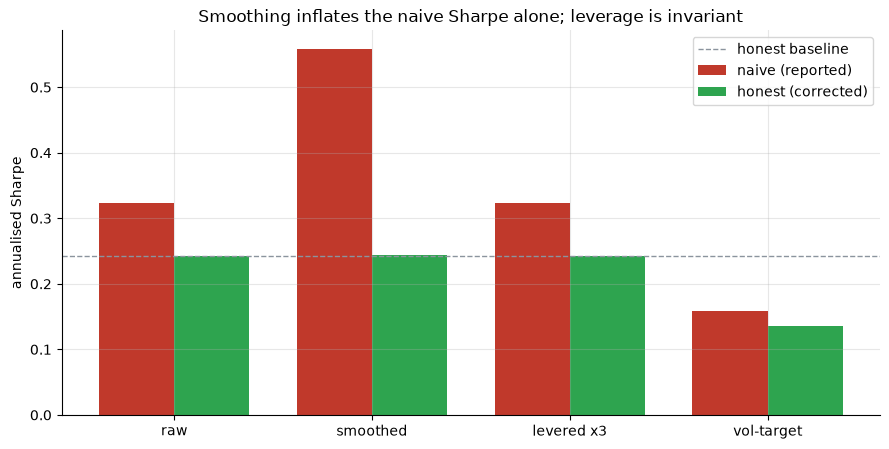

In [2]:
r = RET.to_numpy()
gt = st.gaming_table(r, theta=0.5, leverage=3.0, target_ann_vol=0.10)
print(gt.round(3).to_string())
labels = ['raw', 'smoothed', 'levered x3', 'vol-target']
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(x - w/2, gt['naive_sharpe'], w, color=RED, label='naive (reported)')
ax.bar(x + w/2, gt['honest_sharpe'], w, color=GREEN, label='honest (corrected)')
ax.axhline(gt['honest_sharpe'].iloc[0], ls='--', c=GREY, lw=1, label='honest baseline')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('annualised Sharpe')
ax.set_title('Smoothing inflates the naive Sharpe alone; leverage is invariant')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: **H₁ confirmed** — smoothing lifts the naive Sharpe by +0.236 and the honest by +0.002 (≈0). **H₂ confirmed** — leverage ×3 leaves *both* Sharpes at 0.323 / 0.242, to machine precision. **H₃'s free-lunch reading rejected** — vol-targeting *lowered* the naive Sharpe to 0.158 on this tape.

### 4b · The smoothing dose-response — H₁ and H₄ together

Sweep the smoothing intensity θ and watch the naive Sharpe balloon while the honest one flatlines. The lag-1 autocorrelation is the tell.

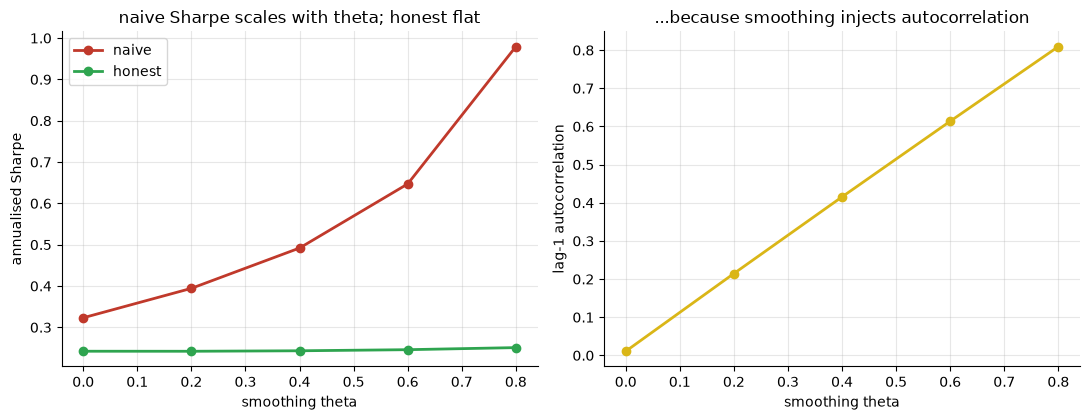

       naive_sharpe  honest_sharpe  lag1_autocorr
theta                                            
0.0           0.323          0.242          0.011
0.2           0.394          0.242          0.215
0.4           0.492          0.243          0.415
0.6           0.647          0.246          0.614
0.8           0.979          0.251          0.809


In [3]:
sw = st.theta_sweep(r, thetas=(0.0, 0.2, 0.4, 0.6, 0.8))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.plot(sw.index, sw['naive_sharpe'], 'o-', c=RED, lw=2, label='naive')
a1.plot(sw.index, sw['honest_sharpe'], 'o-', c=GREEN, lw=2, label='honest')
a1.set_xlabel('smoothing theta'); a1.set_ylabel('annualised Sharpe')
a1.set_title('naive Sharpe scales with theta; honest flat'); a1.legend()
a2.plot(sw.index, sw['lag1_autocorr'], 'o-', c=AMBER, lw=2)
a2.set_xlabel('smoothing theta'); a2.set_ylabel('lag-1 autocorrelation')
a2.set_title('...because smoothing injects autocorrelation')
plt.tight_layout(); plt.show()
print(sw.round(3).to_string())

> 💡 In plain words: **H₁ + H₄ confirmed.** As θ → 0.8 the naive Sharpe reaches **0.979** (a 3× inflation) and the lag-1 autocorrelation reaches **0.81** — the two move together. The honest Sharpe stays ~0.24 throughout: the $\eta$-correction cancels exactly the autocorrelation the naive formula mistakes for skill.

### 4c · The bootstrap bands — which metric is the artefact

A circular-block bootstrap (block 20d) on the θ = 0.5 inflation, read for both metrics.

naive  inflation 0.236  CI [-0.205, 0.629]
honest inflation 0.002  CI [-0.012, 0.013]
frac honest >= naive point: 0.0


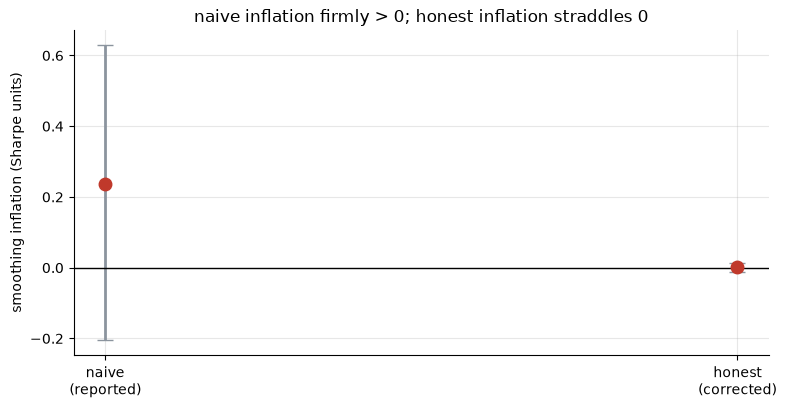

In [4]:
nl = st.smoothing_inflation_null(r, theta=0.5, n_boot=2000, seed=590)
print('naive  inflation %.3f  CI [%.3f, %.3f]' % (nl['naive_inflation'], *nl['naive_ci']))
print('honest inflation %.3f  CI [%.3f, %.3f]' % (nl['honest_inflation'], *nl['honest_ci']))
print('frac honest >= naive point:', nl['frac_honest_ge_naive'])
fig, ax = plt.subplots(figsize=(8, 4.2))
pts = [nl['naive_inflation'], nl['honest_inflation']]
err = [[nl['naive_inflation']-nl['naive_ci'][0], nl['honest_inflation']-nl['honest_ci'][0]],
       [nl['naive_ci'][1]-nl['naive_inflation'], nl['honest_ci'][1]-nl['honest_inflation']]]
ax.errorbar(['naive\n(reported)','honest\n(corrected)'], pts, yerr=err, fmt='o',
            color=RED, ecolor=GREY, capsize=6, ms=9, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('smoothing inflation (Sharpe units)')
ax.set_title('naive inflation firmly > 0; honest inflation straddles 0')
plt.tight_layout(); plt.show()

> 💡 In plain words: the **honest** inflation's 95% CI `[-0.012, 0.013]` **contains zero** — the corrected metric is not fooled — while the **naive** inflation is a firmly-positive +0.236. No bootstrap draw's honest inflation reaches the naive point estimate.

## 5 · The verdict

- **Signal `NONE`** — the only Sharpe gain is a smoothing artefact (naive +0.236, honest +0.002); leverage invariant; vol-targeting negative. Synthetic-only demo — no real tape, so never `REAL`.
- **Tradability `MIRAGE`** — a smoothed Sharpe is unspendable; vol-targeting nets 0.145 after 2 bps; leverage buys risk, not ratio.
- **Can engineering fake a Sharpe? `CONFIRMED`** — the *reported* one, by up to 3×.

## 6 · Could you trade it? — the vol-targeting lever, net

The one lever that *actually trades* (vol-targeting) is below baseline and loses to costs.

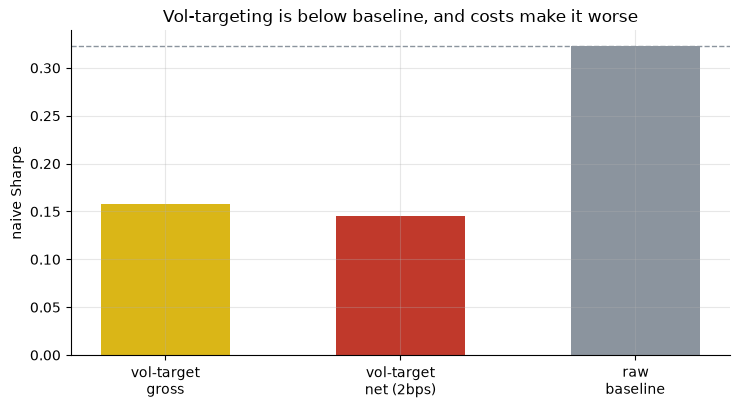

gross 0.158 -> net 0.145 (turnover 0.030/day); raw baseline 0.323


In [5]:
nv = st.net_vol_target(r, target_ann_vol=0.10, cost_bps=2.0)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = [nv['gross_naive_sharpe'], nv['net_naive_sharpe'], st.sharpe_naive(r)]
ax.bar(['vol-target\ngross','vol-target\nnet (2bps)','raw\nbaseline'], bars,
       color=[AMBER, RED, GREY], width=.55)
ax.axhline(st.sharpe_naive(r), ls='--', c=GREY, lw=1)
ax.set_ylabel('naive Sharpe'); ax.set_title('Vol-targeting is below baseline, and costs make it worse')
plt.tight_layout(); plt.show()
print(f"gross {nv['gross_naive_sharpe']:.3f} -> net {nv['net_naive_sharpe']:.3f} "
      f"(turnover {nv['turnover_per_day']:.3f}/day); raw baseline {st.sharpe_naive(r):.3f}")

> 💡 In plain words: vol-targeting genuinely trades (turnover ~0.03/day), so it pays costs — and here it starts *below* the raw Sharpe and only sinks. There is nothing to harvest. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the honest Sharpe just numb to everything, or does it reward a **real** edge? Plant a genuine alpha and check: the honest raw Sharpe must *rise with the edge*, while the smoothing game inflates the *naive* Sharpe by the same mechanical amount regardless — averaged over 25 seeds so no lucky seed can fake it.

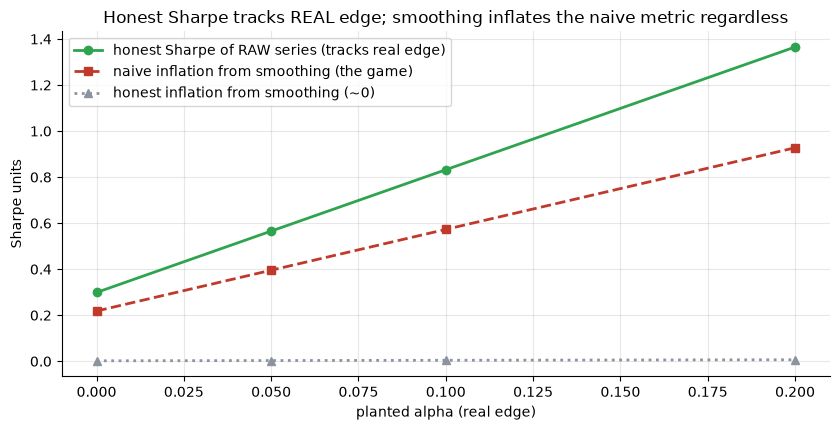

alpha 0.00: honest_raw 0.299 | naive_infl 0.218 | honest_infl 0.0020
alpha 0.05: honest_raw 0.565 | naive_infl 0.396 | honest_infl 0.0031
alpha 0.10: honest_raw 0.832 | naive_infl 0.573 | honest_infl 0.0043
alpha 0.20: honest_raw 1.365 | naive_infl 0.927 | honest_infl 0.0066


In [6]:
alphas = [0.0, 0.05, 0.10, 0.20]
rows = [st.seed_robust_control(data, alpha=a, n_seeds=25) for a in alphas]
hr = [x['mean_honest_raw'] for x in rows]
ni = [x['mean_naive_inflation'] for x in rows]
hi = [x['mean_honest_inflation'] for x in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(alphas, hr, 'o-', c=GREEN, lw=2, label='honest Sharpe of RAW series (tracks real edge)')
ax.plot(alphas, ni, 's--', c=RED, lw=2, label='naive inflation from smoothing (the game)')
ax.plot(alphas, hi, '^:', c=GREY, lw=2, label='honest inflation from smoothing (~0)')
ax.set_xlabel('planted alpha (real edge)'); ax.set_ylabel('Sharpe units')
ax.set_title('Honest Sharpe tracks REAL edge; smoothing inflates the naive metric regardless')
ax.legend(); plt.tight_layout(); plt.show()
for a, x in zip(alphas, rows):
    print(f"alpha {a:.2f}: honest_raw {x['mean_honest_raw']:.3f} | "
          f"naive_infl {x['mean_naive_inflation']:.3f} | honest_infl {x['mean_honest_inflation']:.4f}")

The **honest** Sharpe of the raw series climbs 0.30 → 1.37 with the planted edge — the correction rewards genuine skill. The **naive** smoothing inflation stays large (~0.22 → 0.93) *whether or not* there's real edge — it's a pure measurement game — while the **honest** inflation is a negligible ~0.002–0.007 throughout. So the corrected Sharpe is a faithful detector: it sees through the smoothing game *and* still banks a real edge. For the *searching* way to fake a Sharpe, see [344 Backtest-Overfitting](../../344-backtest-overfitting/) and [589 Genetic-Algo-Overfit](../../589-genetic-algo-overfit/).